# 1) Load the data into a dataframe df, show its size and head, eliminate the rows containing null values and show the number of remaining rows

In [122]:
import pandas as pd
df = pd.read_csv("./country_stats.csv")

initial_shape = df.shape
print(f"Initial size: {initial_shape}")
display(df.head())

df.dropna(inplace=True)
final_shape = df.shape
print(f"Final size: {final_shape}")

Initial size: (242, 8)


,Country Name,GDP at market prices (constant 2005 US$),GDP at market prices (current US$),GDP per capita (constant 2005 US$),GDP per capita (current US$),Internet users (per 100 people),Population growth (annual %),"Population, total"
0,Afghanistan,1.593680e+10,1.593680e+10,553.300289,553.300289,4.0,2.812617,28803167.0
1,Albania,1.192695e+10,1.192695e+10,4094.358832,4094.358832,45.0,-0.496462,2913021.0
2,Algeria,1.612073e+11,1.612073e+11,4463.394675,4463.394675,12.5,1.821358,36117637.0
3,American Samoa,5.760000e+08,5.760000e+08,10352.822762,10352.822762,NaN,-1.054862,55637.0
4,Andorra,3.355695e+09,3.355695e+09,39736.354063,39736.354063,81.0,-0.015393,84449.0


Final size: (221, 8)


# 2) Produce a pairplot of the numeric columns of dfand comment relevant situations

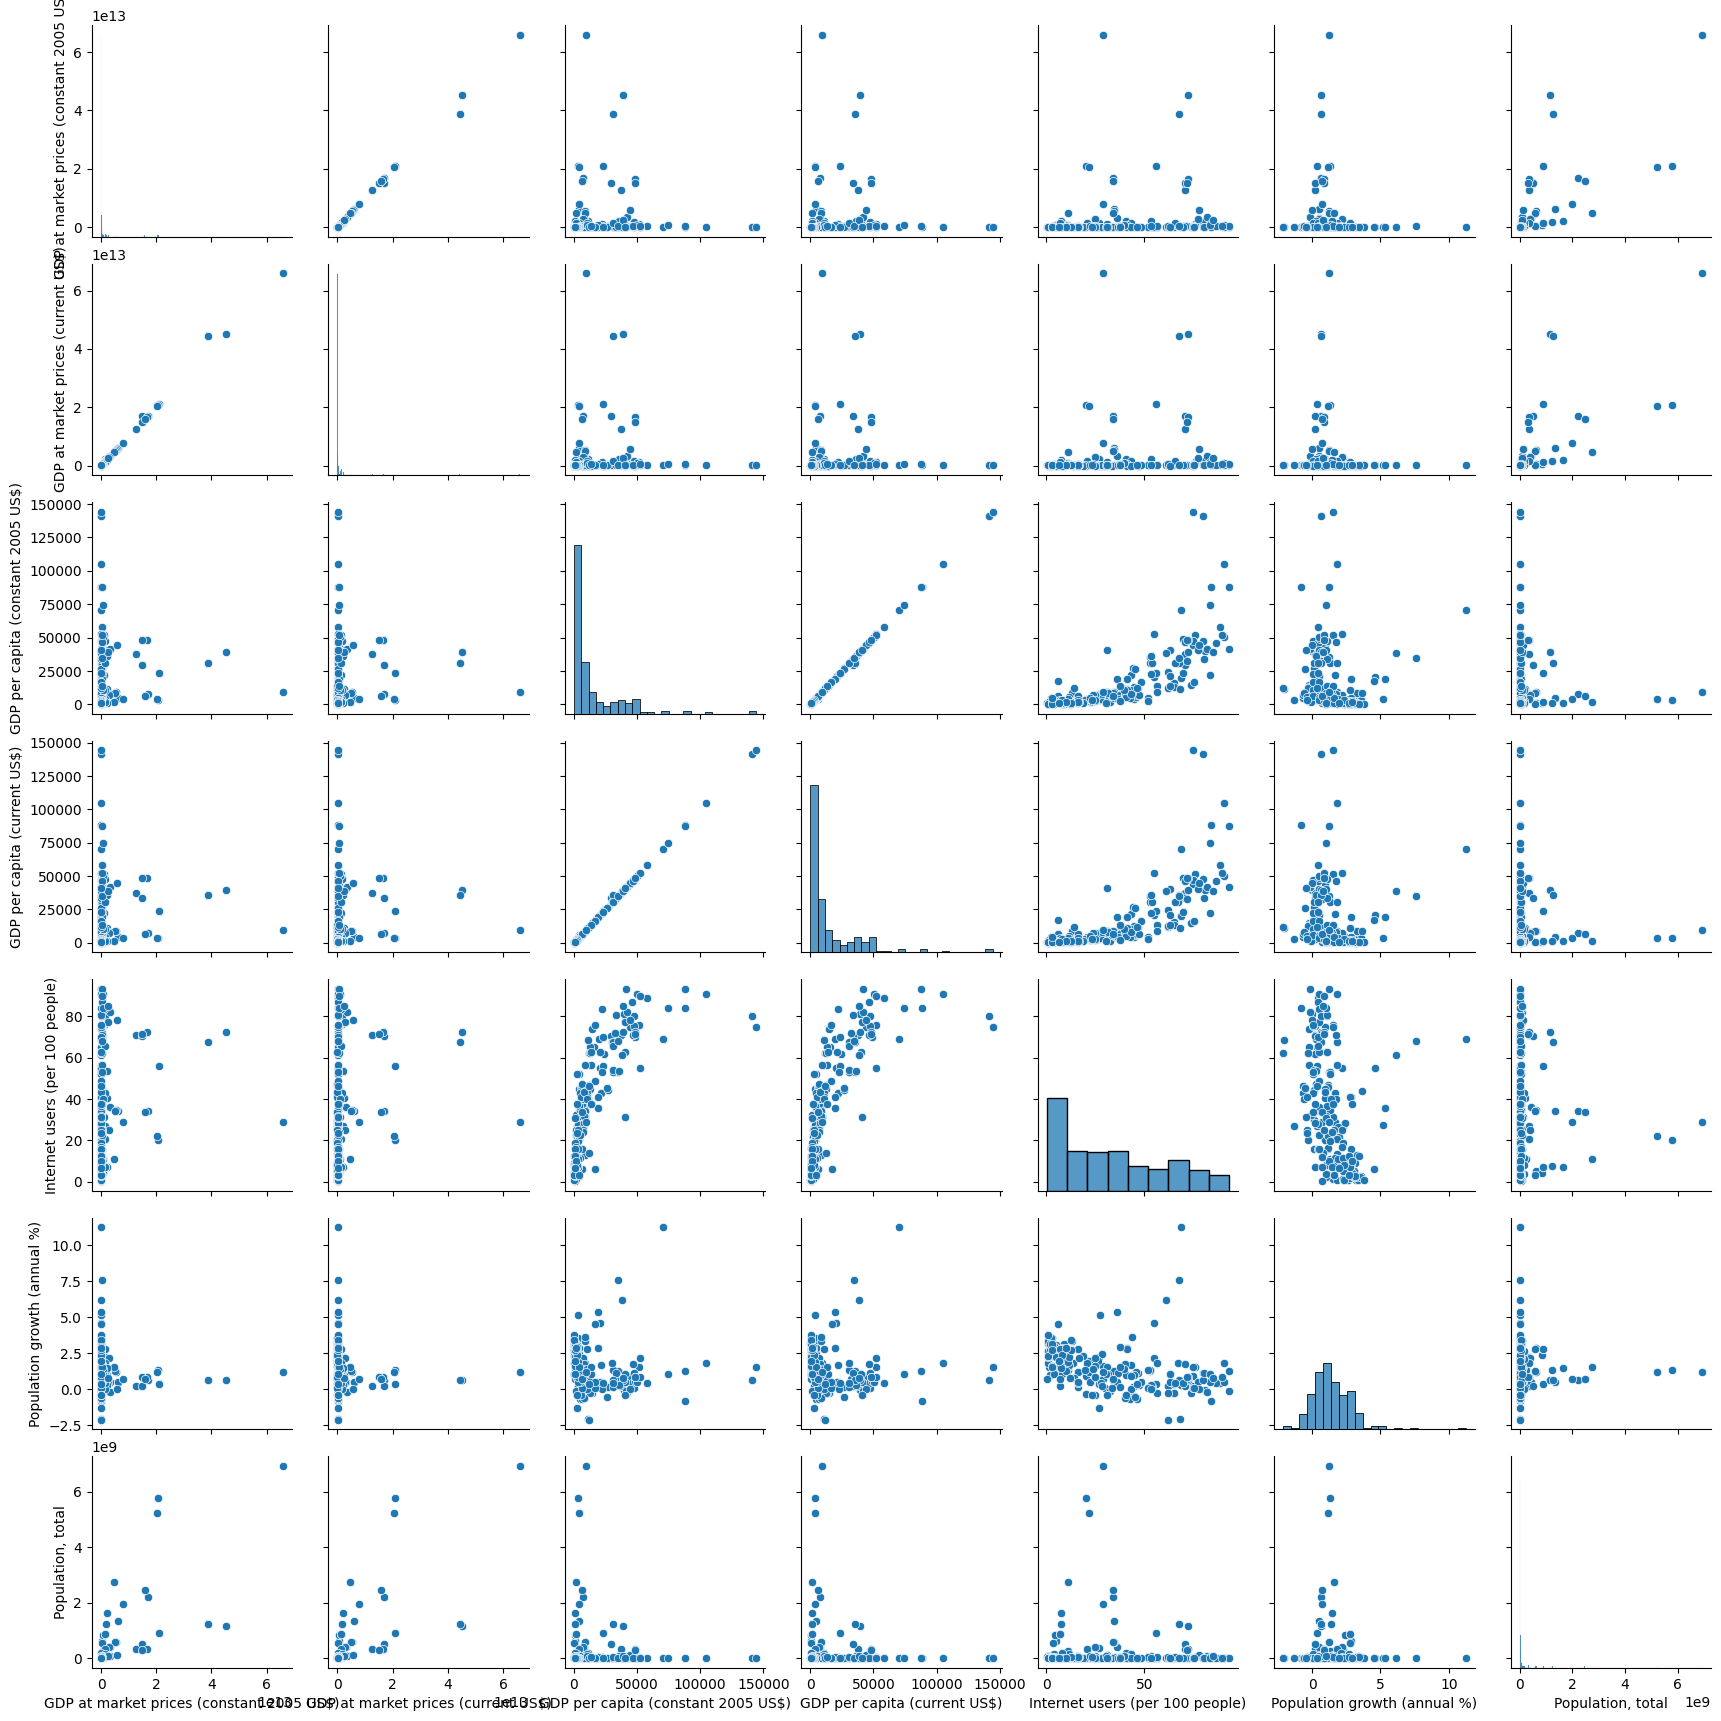

In [123]:
num_cols = df.select_dtypes(include=['number']).columns
df_num = df[num_cols]

import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.pairplot(data=df_num);

We can notice that the data are not centered, there are not clear clusters and the dimensions have different magnitudes.

# 3) Produce a box plot of the numeric columns of df and comment relevant situations

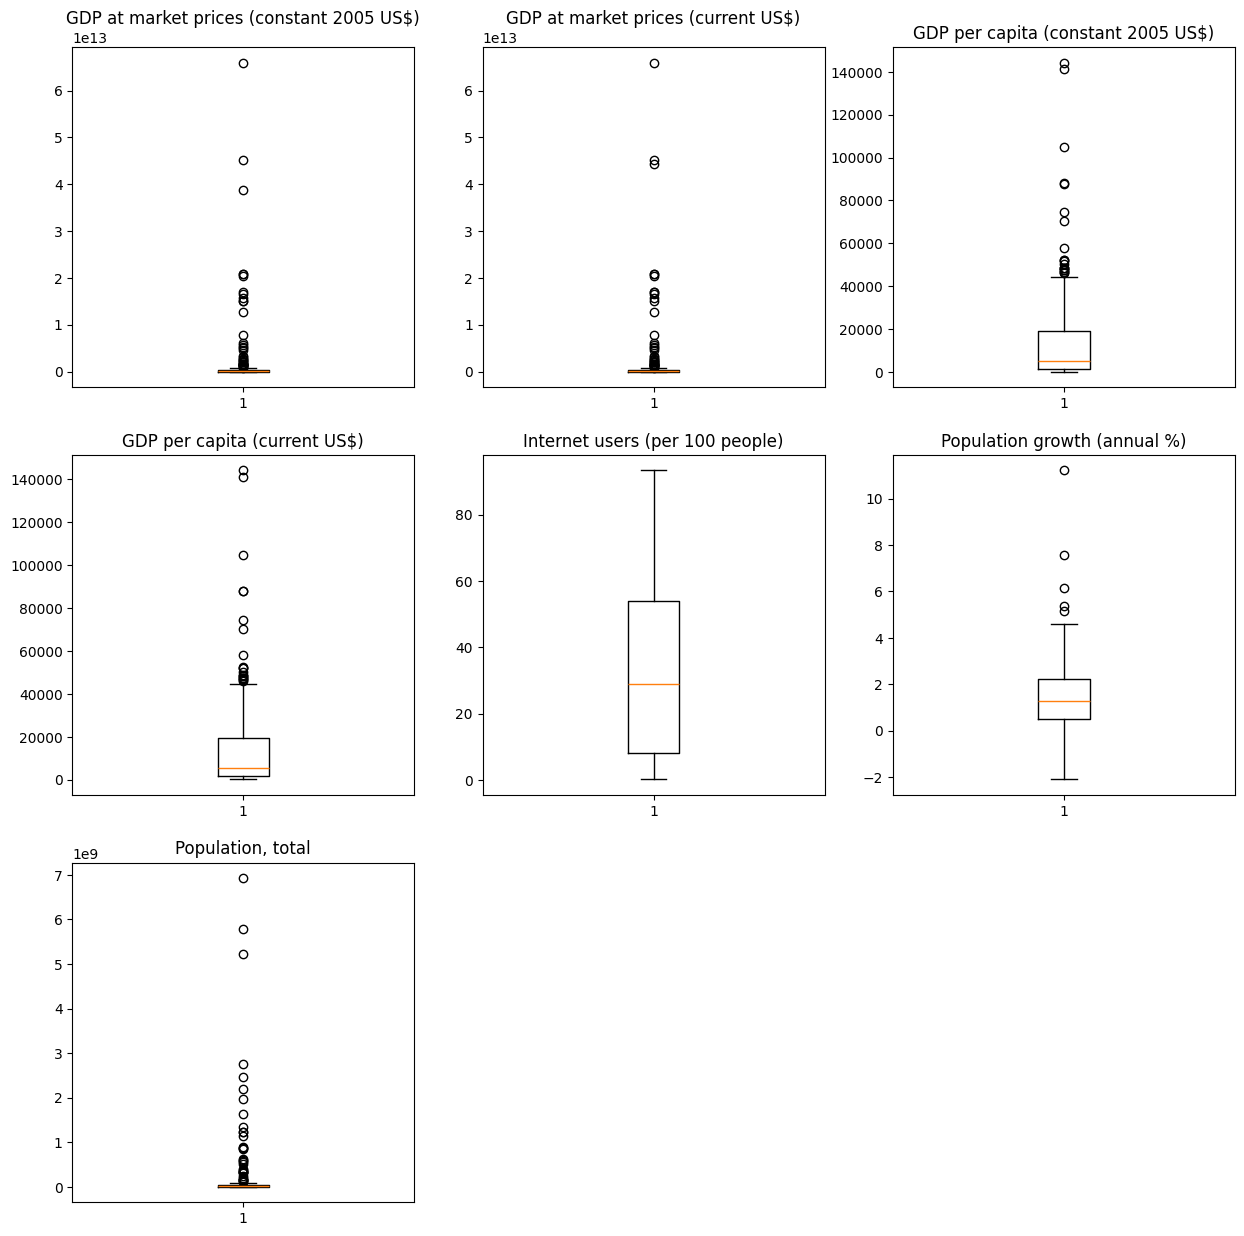

In [124]:
import matplotlib.pyplot as plt
fig,axes = plt.subplots(3,3, figsize=(15,15))
axes = axes.flatten()
for i,c in enumerate(num_cols):
    axes[i].set_title(c)
    axes[i].boxplot(x=df_num[c])
    
for i in range(len(num_cols), 9):
    fig.delaxes(axes[i])

Most of the attributes have several outliers.

# 4) Produce the correlation matrix of the data andeliminatetheredundant attributes, if it is adequate

- if attributes aand bhave high correlation (e.g. absolute value higher than 0.95) one of the two can be eliminated

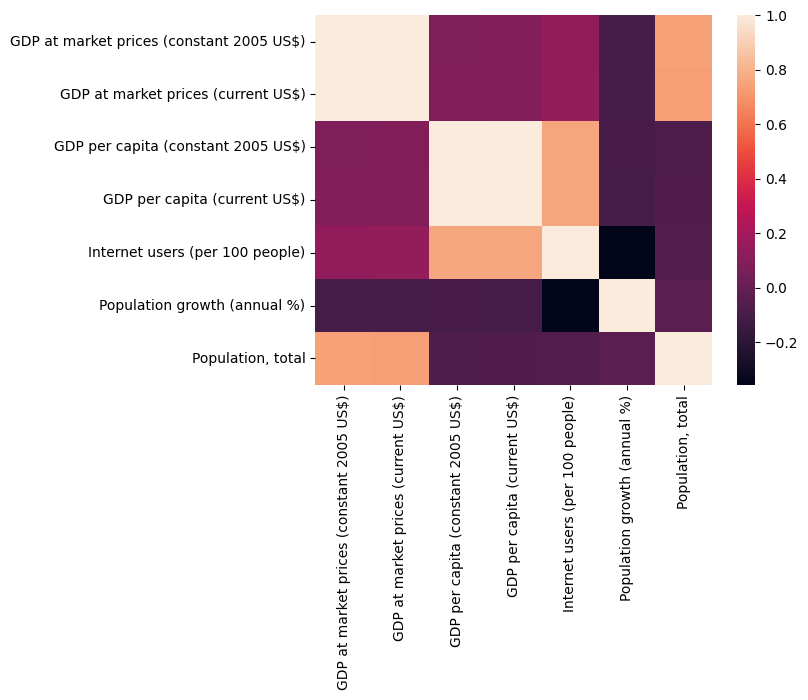

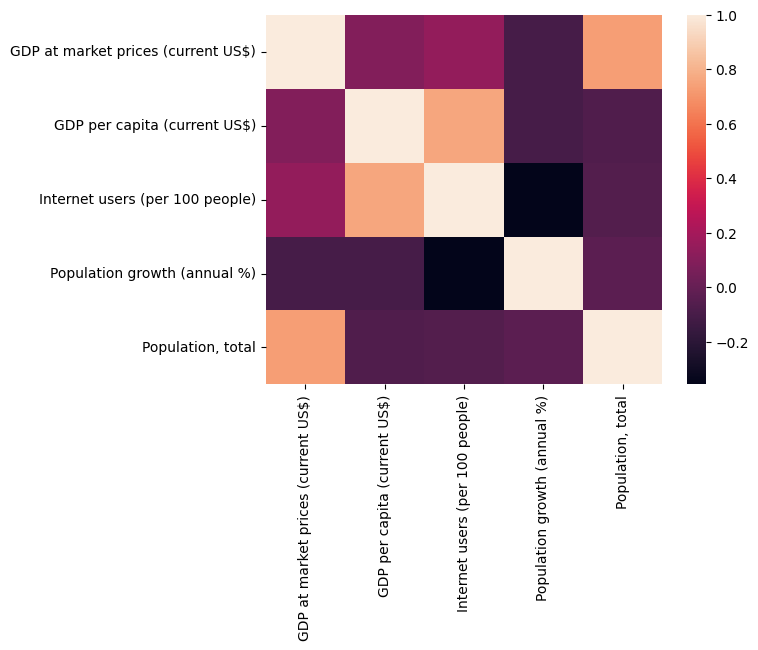

In [125]:
corr = df_num.corr()
sns.heatmap(corr)
plt.show()

correlated_attributes = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if corr.iloc[i,j] >= 0.95:
            # Delete the second attribute in the couple
            if num_cols[j] not in correlated_attributes:
                correlated_attributes.append(num_cols[i])
df_num_cleaned = df_num.drop(labels=correlated_attributes, axis=1)

corr_cleaned = df_num_cleaned.corr()
sns.heatmap(corr_cleaned);

# 5) Split the reduced data: store the first column in a vector keysand the others in a matrix X

In [126]:
keys = df["Country Name"]
X = df_num_cleaned

# 6) Find the best clustering scheme for the data (possibly reduced after step 4) with a method of your choice, plot global silhouette index for an appropriate range of hyperparameter(s) and show the chosen hyperparameter(s)

In [127]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

random_state=42
ks = [*range(2,11)]
silhouette_list = []
inertia_list = []
for k in ks:
    model = KMeans(n_clusters=k, random_state=random_state)
    y_km = model.fit_predict(X)
    inertia_list.append(model.inertia_)
    silhouette_list.append(silhouette_score(X, y_km))

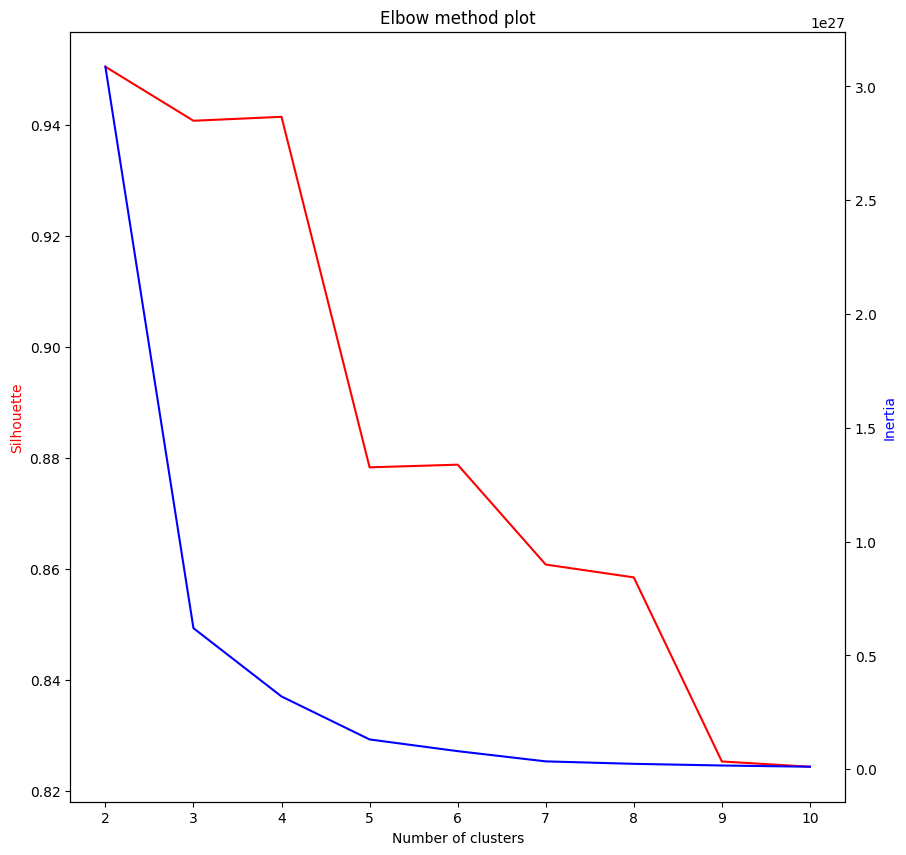

In [128]:
fig, ax1 = plt.subplots(1,1, figsize=[10,10])
ax1.set_title("Elbow method plot")

color="r"
ax1.plot(ks, silhouette_list, c=color)
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Silhouette", c=color)
# ax1.set_ylim(0,1)

color="b"
ax2 = ax1.twinx()
ax2.plot(ks, inertia_list, c=color)
ax2.set_ylabel("Inertia", c=color)

plt.show()

We can see the elbow in $K=3$

# 7) Fit the clustering scheme to y, then produce the silhouette plot using the functionplot_silhouette contained in the attached file

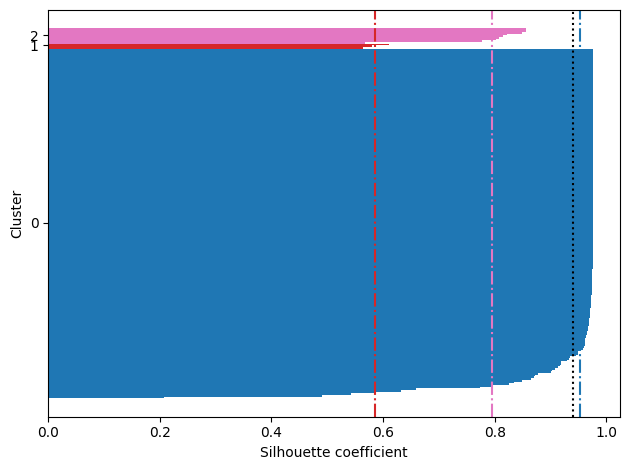

In [129]:
from plot_silhouette import plot_silhouette
from sklearn.metrics import silhouette_samples
y_KM = KMeans(n_clusters=3, random_state=random_state).fit_predict(X)
plot_silhouette(silhouette_samples(X, y_KM), y_KM)

# 8) Perform a logarithmic transformation of the data
- This means simply to apply the logfunction of numpy
- If one of the columns has zero or negative values, avoid its transformation

In [130]:
import numpy as np
X_log = X.copy()
for c in X_log.columns:
    col = X_log[c]
    mask = col[col<=0]
    if np.sum(mask)==0 : 
        X_log[c] = np.log(col)

# 9) Repeat points 6 and 7 above and comment the comparison with the result of point 6

In [131]:
random_state=42
ks = [*range(2,11)]
silhouette_list = []
inertia_list = []
for k in ks:
    model = KMeans(n_clusters=k, random_state=random_state)
    y_km = model.fit_predict(X_log)
    inertia_list.append(model.inertia_)
    silhouette_list.append(silhouette_score(X_log, y_km))

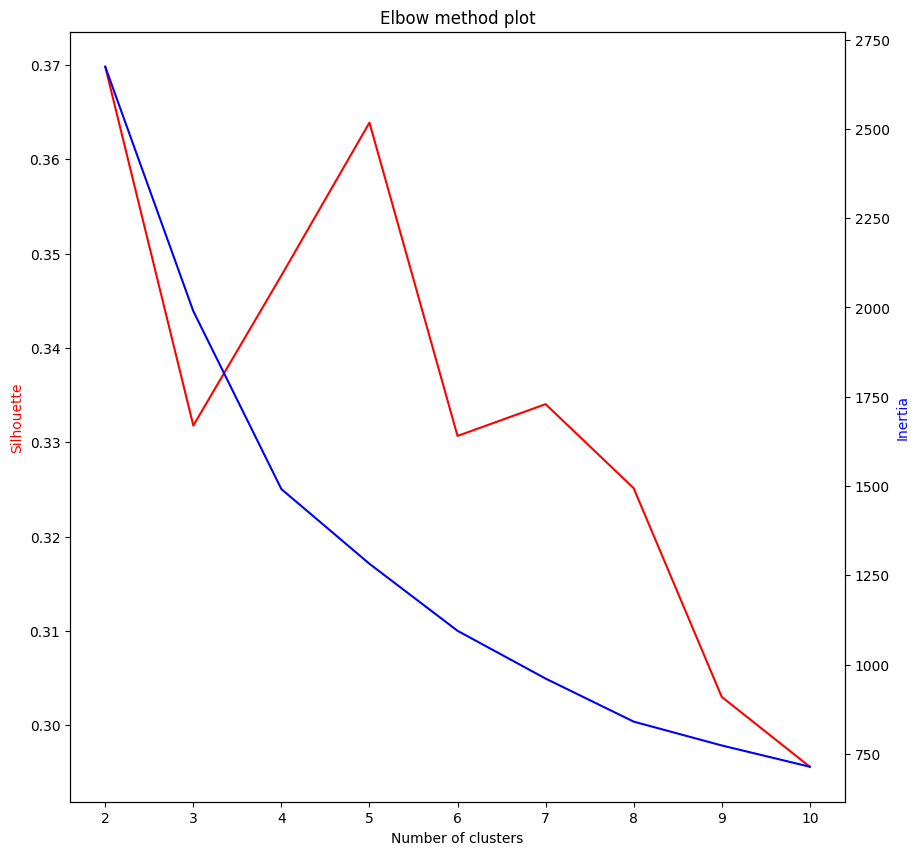

In [134]:
fig, ax1 = plt.subplots(1,1, figsize=[10,10])
ax1.set_title("Elbow method plot")

color="r"
ax1.plot(ks, silhouette_list, c=color)
ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Silhouette", c=color)
# ax1.set_ylim(0,1)

color="b"
ax2 = ax1.twinx()
ax2.plot(ks, inertia_list, c=color)
ax2.set_ylabel("Inertia", c=color)

plt.show()

We can notice that the silhouette score is much lower than before.

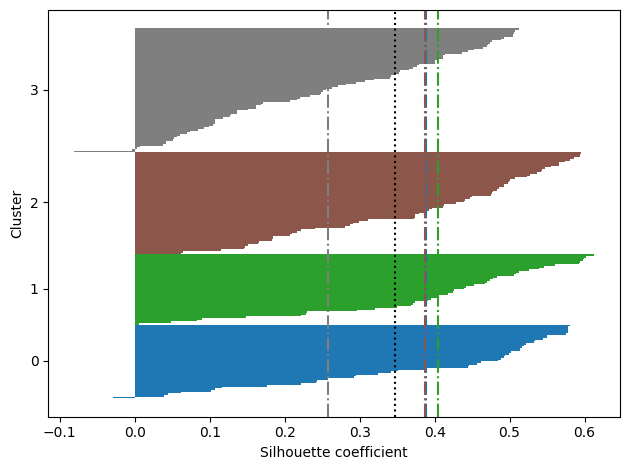

In [135]:
y_KM = KMeans(n_clusters=4, random_state=random_state).fit_predict(X_log)
plot_silhouette(silhouette_samples(X_log, y_KM), y_KM)

We can notice that by applying this transformation to the data the clusters are more balanced than before.

## NOTE

What we said can be seen also by plotting pairplots as boxplots again

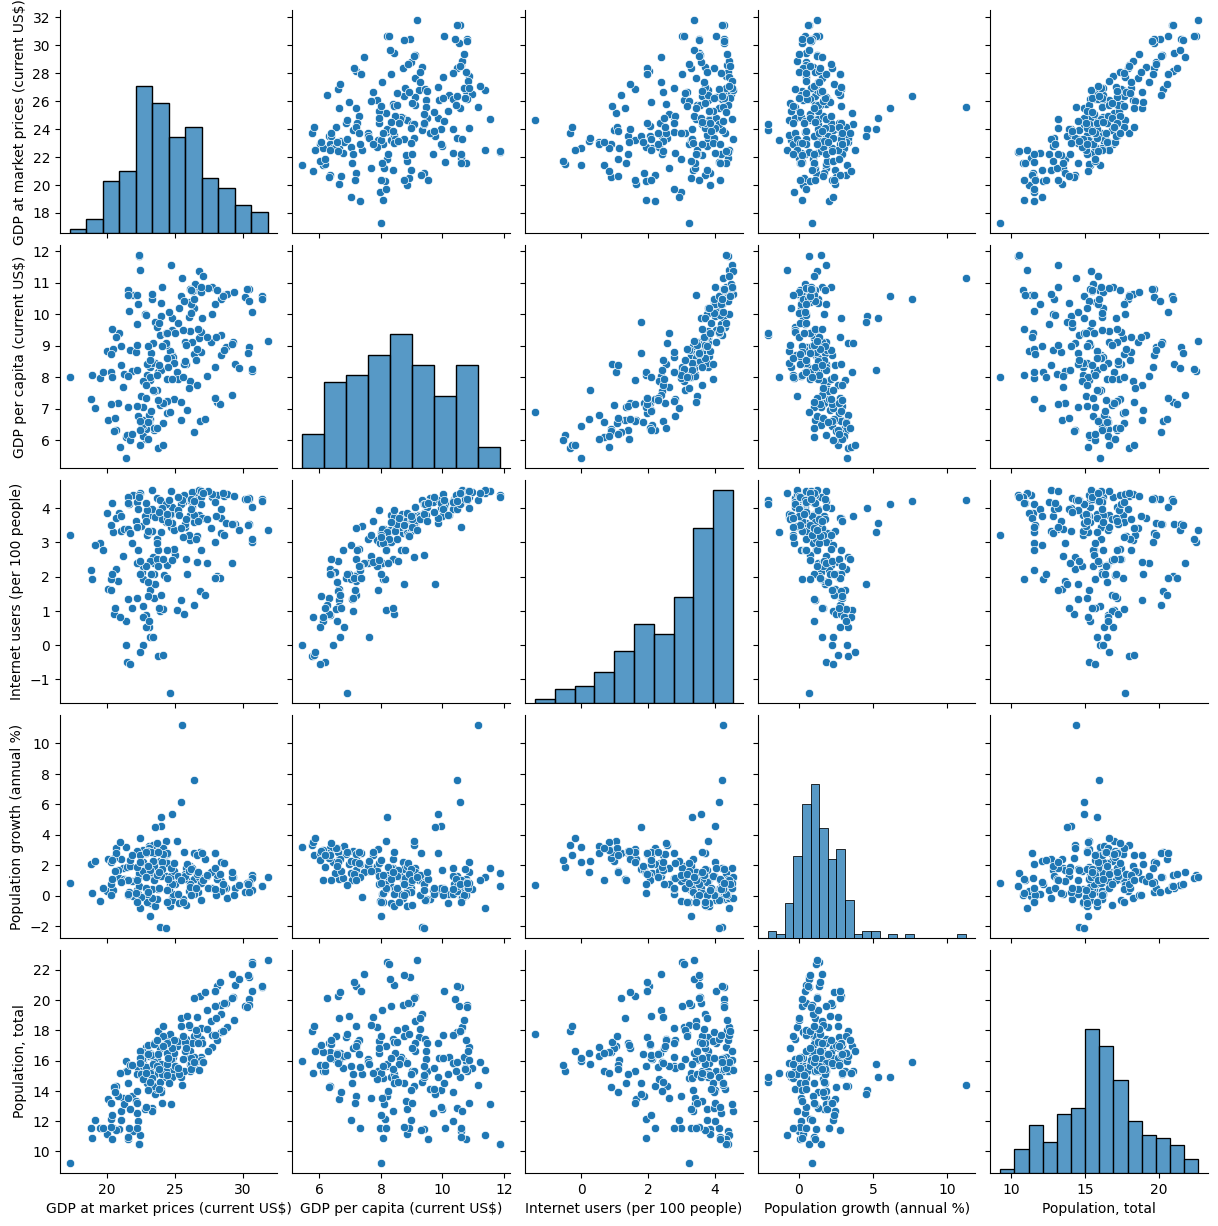

In [132]:
sns.pairplot(data=X_log);

Now the data are centered ad the distribution are balanced

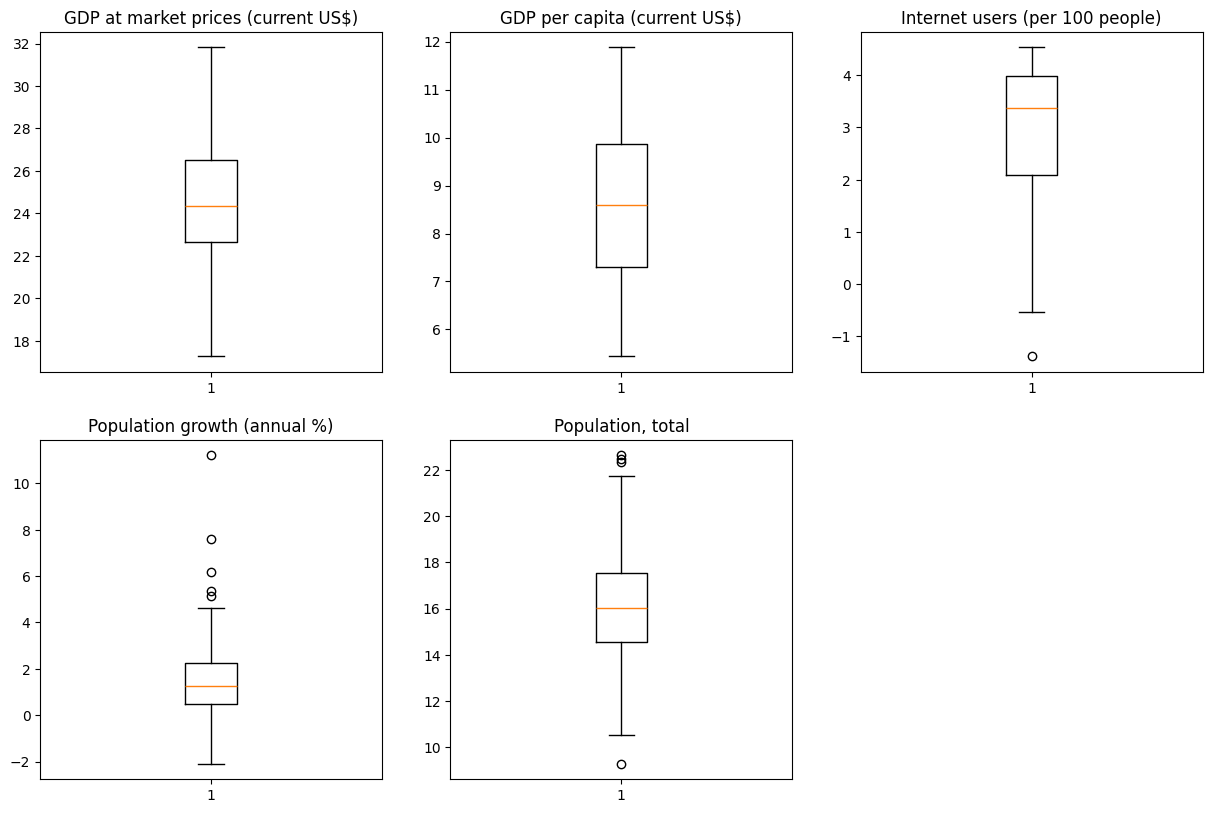

In [133]:
fig,axes = plt.subplots(3,3, figsize=(15,15))
axes = axes.flatten()
for i,c in enumerate(X_log.columns):
    axes[i].set_title(c)
    axes[i].boxplot(x=X_log[c])
    
for i in range(len(X_log.columns), 9):
    fig.delaxes(axes[i])

We have fewer outliers than before.